# Task 2: Feature Engineering, Model Optimization & Performance Comparison
### California Housing Dataset | Maincrafts Technology
**Objective:** Compare Linear Regression, Ridge Regression and Decision Tree models with feature scaling.

In [27]:
# Step 1: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
print("All libraries imported successfully!")

All libraries imported successfully!


In [28]:
# Step 2: Load the California Housing dataset
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [29]:
# Step 3: Separate features (X) and target (y)
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (20640, 8)
Target shape: (20640,)

Feature columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Feature Scaling
Bringing all features to the same scale so no single feature dominates due to its numeric range.

In [30]:
# Step 4: Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Before scaling - MedInc range:")
print(f"  Min: {X['MedInc'].min():.2f}, Max: {X['MedInc'].max():.2f}")
print("\nBefore scaling - Population range:")
print(f"  Min: {X['Population'].min():.2f}, Max: {X['Population'].max():.2f}")
print("\nAfter scaling - MedInc range:")
print(f"  Min: {X_scaled[:, 0].min():.2f}, Max: {X_scaled[:, 0].max():.2f}")
print("\nAfter scaling - Population range:")
print(f"  Min: {X_scaled[:, 4].min():.2f}, Max: {X_scaled[:, 4].max():.2f}")

Before scaling - MedInc range:
  Min: 0.50, Max: 15.00

Before scaling - Population range:
  Min: 3.00, Max: 35682.00

After scaling - MedInc range:
  Min: -1.77, Max: 5.86

After scaling - Population range:
  Min: -1.26, Max: 30.25


In [31]:
# Step 5: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
     X_scaled, y, test_size=0.2, random_state=42)
print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows:     {X_test.shape[0]}")

Training rows: 16512
Test rows:     4128


## Model Training & Comparison
Training 3 models and evaluating each on the same test set for a fair comparison.

In [32]:
# Step 6: Train multiple models and compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}
results = {}
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    predictions = model.predict(X_test)
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    # Store results
    results[name] = {"RMSE": round(rmse, 4), "R2 Score": round(r2, 4)}
    print(f"{name}:")
    print(f"  RMSE: {rmse:.4f} (${rmse*100000:,.0f})")
    print(f"  R2:   {r2:.4f} ({r2*100:.1f}% variance explained)")
    print()
# Show comparison table
results_df = pd.DataFrame(results).T
print("=== MODEL COMPARISON TABLE ===")
print(results_df)

Linear Regression:
  RMSE: 0.7456 ($74,558)
  R2:   0.5758 (57.6% variance explained)

Ridge Regression:
  RMSE: 0.7456 ($74,555)
  R2:   0.5758 (57.6% variance explained)

Decision Tree:
  RMSE: 0.7242 ($72,423)
  R2:   0.5997 (60.0% variance explained)

=== MODEL COMPARISON TABLE ===
                     RMSE  R2 Score
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758
Decision Tree      0.7242    0.5997


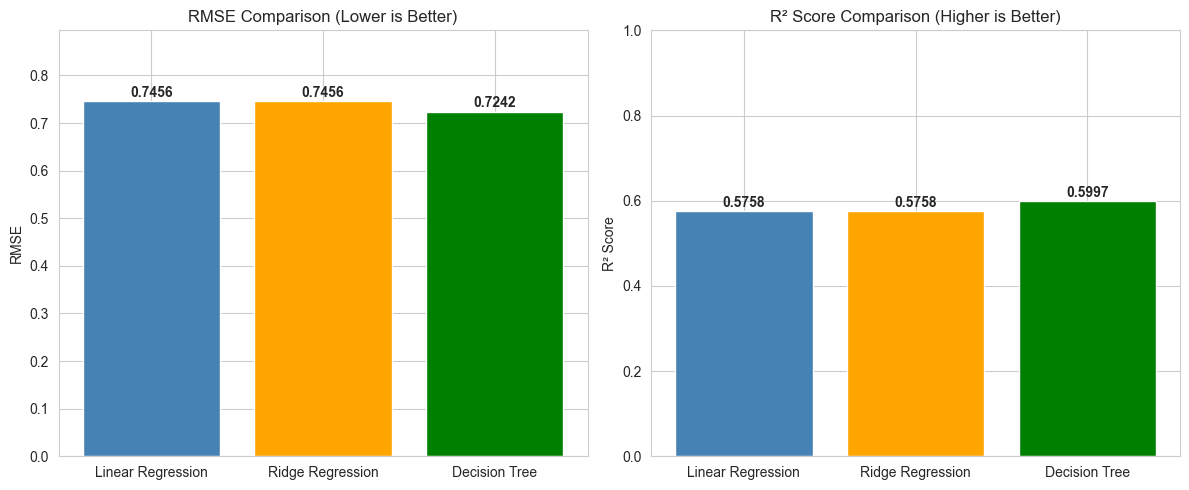

In [33]:
# Step 7: Visual comparison of models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# RMSE chart (lower is better)
axes[0].bar(results_df.index, results_df["RMSE"], 
            color=["steelblue", "orange", "green"])
axes[0].set_title("RMSE Comparison (Lower is Better)")
axes[0].set_ylabel("RMSE")
axes[0].set_ylim(0, results_df["RMSE"].max() * 1.2)
for i, v in enumerate(results_df["RMSE"]):
    axes[0].text(i, v + 0.01, str(v), ha='center', fontweight='bold')
# R2 chart (higher is better)
axes[1].bar(results_df.index, results_df["R2 Score"], 
            color=["steelblue", "orange", "green"])
axes[1].set_title("R² Score Comparison (Higher is Better)")
axes[1].set_ylabel("R² Score")
axes[1].set_ylim(0, 1)
for i, v in enumerate(results_df["R2 Score"]):
    axes[1].text(i, v + 0.01, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

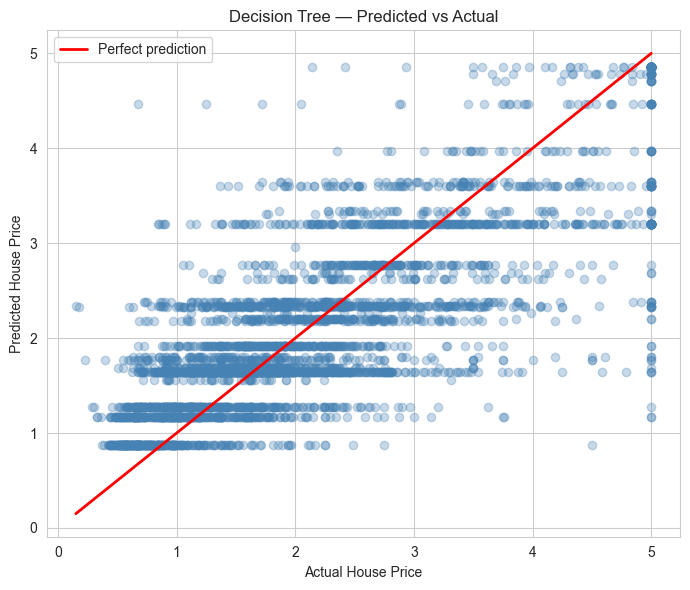

In [34]:
# Step 8: Predicted vs Actual for best model
best_model = DecisionTreeRegressor(max_depth=5)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect prediction')
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Decision Tree — Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.savefig("best_model_pred_vs_actual.png")
plt.show()

In [35]:
# Step 9: Save the best performing model
joblib.dump(best_model, 'best_model.pkl')
print("Best model saved as best_model.pkl")
# Summary
print("\n=== FINAL SUMMARY ===")
print(results_df)
print(f"\nBest Model: Decision Tree")
print(f"Reason: Highest R² and lowest RMSE")
print(f"Key improvement over Task 1 Linear Regression:")
print(f"  Task 1 R²: 0.5758 → Task 2 Decision Tree R²: {results_df.loc['Decision Tree','R2 Score']}")

Best model saved as best_model.pkl

=== FINAL SUMMARY ===
                     RMSE  R2 Score
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758
Decision Tree      0.7242    0.5997

Best Model: Decision Tree
Reason: Highest R² and lowest RMSE
Key improvement over Task 1 Linear Regression:
  Task 1 R²: 0.5758 → Task 2 Decision Tree R²: 0.5997


## Conclusion
- **Best Model:** Decision Tree (RMSE: 0.7242, R²: 0.5997)
- **Key Insight:** Linear and Ridge performed identically — no overfitting present
- **Improvement over Task 1:** R² increased from 57.6% to 59.9% using Decision Tree
- **Next step:** Try Random Forest or XGBoost for further improvement